✅ Библиотеки загружены


✅ Данные загружены. Записей: 146
📊 Размерность X_train: (122, 13)
📊 Размерность X_test: (12, 13)

3. SHAP-АНАЛИЗ (RIDGE-РЕГРЕССИЯ)

✅ Модель Ridge обучена

🔍 Расчет SHAP-значений...

📊 ТОП-5 ПРИЗНАКОВ ПО SHAP (RIDGE):
     feature  shap_importance
 DEPOS_lag_1     14531.178824
 DEPOS_lag_3      7846.655784
 DEPOS_lag_6      3865.294134
        SERV      1725.177457
DEPOS_lag_12      1072.438149

📊 Визуализация SHAP...


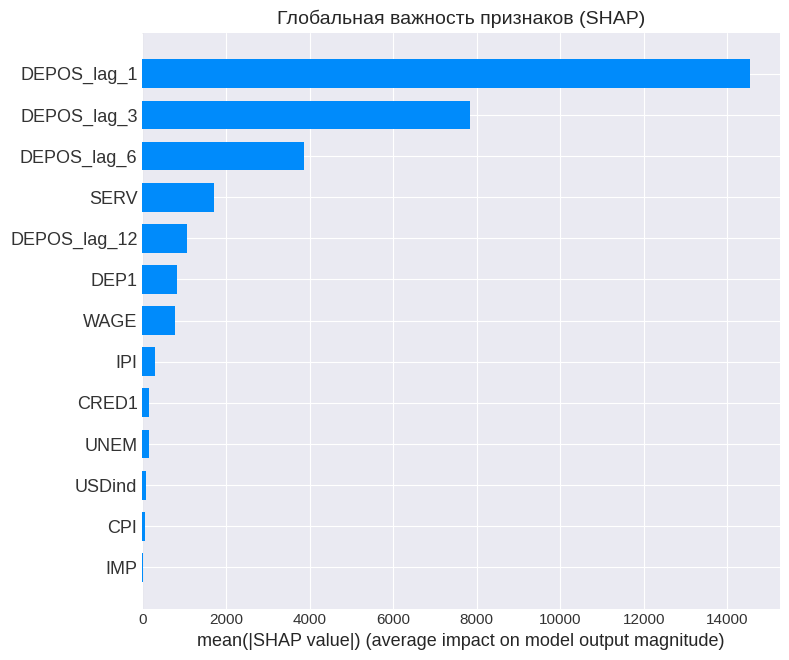

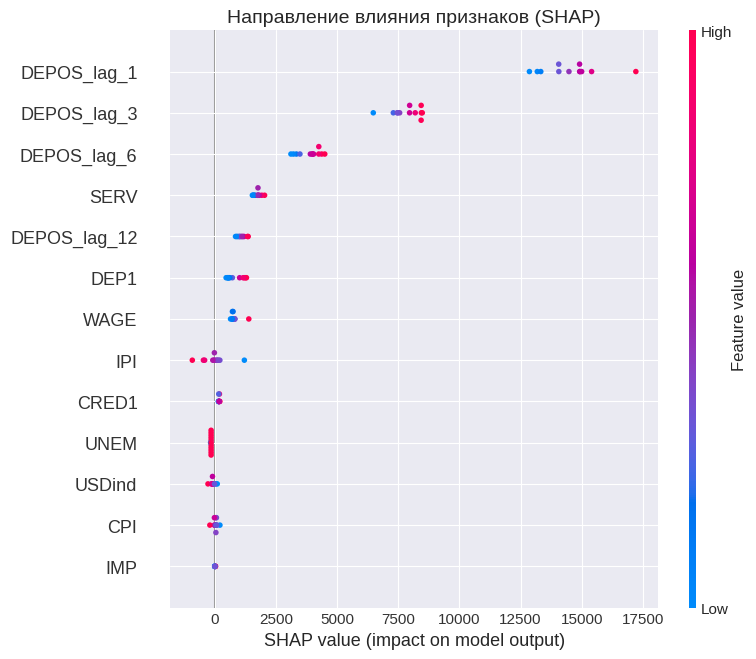

<Figure size 800x600 with 0 Axes>

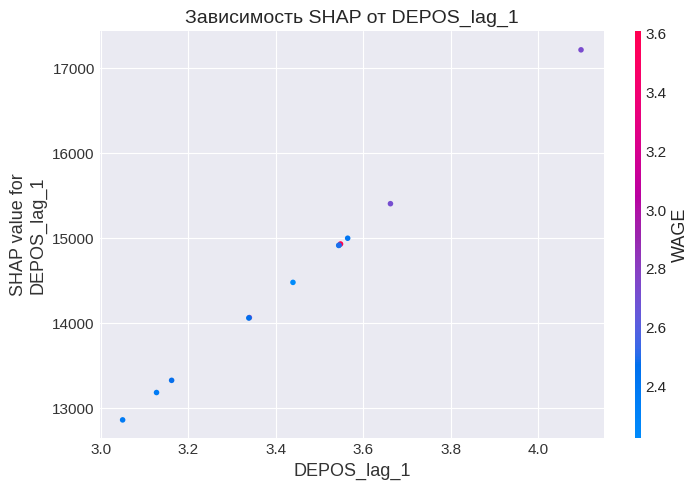


✅ SHAP-анализ завершен

4. АНАЛИЗ НЕЛИНЕЙНЫХ СВЯЗЕЙ

🔍 Базовая линейная модель (из EDA):
   R² = 0.8433
   RMSE = 932.00 млрд руб.

🔍 Тест Рамсея (проверка на пропущенные нелинейности)...

📊 Результаты теста Рамсея:
   y_pred²: F-статистика = 4537.5688, p-значение = 0.0000
   y_pred³: F-статистика = 1309.3157, p-значение = 0.0000
   📌 ВЫВОД: Есть пропущенные нелинейности (p < 0.05)
   → Рекомендуется рассмотреть полиномиальные признаки

🔍 Модель со всеми полиномами (degree=2) — ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ...

📊 Результаты модели со всеми полиномами:
   R² = -32.3413
   RMSE = 13596.51 млрд руб.
   ⚠️ ВНИМАНИЕ: R² < 0 → модель переобучена!

🔍 Lasso-регуляризация (автоматический отбор признаков)...
📊 Число отобранных признаков: 98 из 104
   R² = -6.0706
   RMSE = 6261.31 млрд руб.

🔍 Модель с признаками из EDA-гипотез...

📊 Результаты модели с гипотезами:
   R² = -0.1274
   RMSE = 2500.21 млрд руб.
   Улучшение R² относительно базовой: -0.9707

🔍 Проверка каждой гипотезы по отдельности:
 

In [5]:
# ============================================================
# БЛОК 3: ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ
# Проект: Прогнозирование объема вкладов населения РФ
# Автор: Надежда Силкина
# Дата: 2026
# ============================================================

# ============================================================
# 1. ПОДКЛЮЧЕНИЕ БИБЛИОТЕК
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
import shap
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Библиотеки загружены")

# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ И ПОДГОТОВКА
# ============================================================

url = 'https://raw.githubusercontent.com/HopeSilkina/deposits_forecast_project/main/data/processed_deposits_data.xlsx'
df = pd.read_excel(url, sheet_name='data')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Создание признаков (лаги)
df['DEPOS_log'] = np.log(df['DEPOS'])
for lag in [1, 3, 6, 12]:
    df[f'DEPOS_lag_{lag}'] = df['DEPOS'].shift(lag)

# Подготовка X и y
X = df.drop(['DEPOS', 'DEPOS_log'], axis=1).dropna()
y = df.loc[X.index, 'DEPOS']

# Разделение на train/test
train_size = len(X) - 12
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Масштабирование (для Ridge и Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Данные загружены. Записей: {len(df)}")
print(f"📊 Размерность X_train: {X_train.shape}")
print(f"📊 Размерность X_test: {X_test.shape}")

# ============================================================
# 3. SHAP-АНАЛИЗ (ДЛЯ ЛУЧШЕЙ МОДЕЛИ — RIDGE)
# ============================================================

print("\n" + "="*60)
print("3. SHAP-АНАЛИЗ (RIDGE-РЕГРЕССИЯ)")
print("="*60)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

print("\n✅ Модель Ridge обучена")

# SHAP-анализ
print("\n🔍 Расчет SHAP-значений...")
explainer = shap.LinearExplainer(ridge_model, X_train_scaled, feature_names=X.columns)
shap_values = explainer.shap_values(X_test_scaled)

# Топ-5 признаков по SHAP
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\n📊 ТОП-5 ПРИЗНАКОВ ПО SHAP (RIDGE):")
print(shap_importance.head(5).to_string(index=False))

# 3.3. Визуализация SHAP
print("\n📊 Визуализация SHAP...")

# График 1: Глобальная важность признаков
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar", show=False)
plt.title('Глобальная важность признаков (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# График 2: Направление влияния
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title('Направление влияния признаков (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# График 3: Зависимость SHAP от значения признака (для топ-1)
top_feature = shap_importance.iloc[0]['feature']
plt.figure(figsize=(8, 6))
shap.dependence_plot(top_feature, shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title(f'Зависимость SHAP от {top_feature}', fontsize=14)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ SHAP-анализ завершен")

# ============================================================
# 4. АНАЛИЗ НЕЛИНЕЙНОСТЕЙ
# ============================================================

print("\n" + "="*60)
print("4. АНАЛИЗ НЕЛИНЕЙНЫХ СВЯЗЕЙ")
print("="*60)

# 4.0. Базовая модель
print("\n🔍 Базовая линейная модель (из EDA):")
lr_base = LinearRegression()
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)
r2_base = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"   R² = {r2_base:.4f}")
print(f"   RMSE = {rmse_base:.2f} млрд руб.")

# 4.1. Тест Рамсея (RESET test)
print("\n🔍 Тест Рамсея (проверка на пропущенные нелинейности)...")

# Получаем предсказания базовой модели на обучающей выборке
y_train_pred_base = lr_base.predict(X_train)

# Добавляем степени предсказанных значений
X_train_reset = X_train.copy()
X_train_reset['y_pred2'] = y_train_pred_base ** 2
X_train_reset['y_pred3'] = y_train_pred_base ** 3

# Обучаем модель с добавленными степенями
lr_reset = LinearRegression()
lr_reset.fit(X_train_reset, y_train)

# Проверяем значимость добавленных признаков
from sklearn.feature_selection import f_regression
f_values, p_values = f_regression(X_train_reset[['y_pred2', 'y_pred3']], y_train)

print(f"\n📊 Результаты теста Рамсея:")
print(f"   y_pred²: F-статистика = {f_values[0]:.4f}, p-значение = {p_values[0]:.4f}")
print(f"   y_pred³: F-статистика = {f_values[1]:.4f}, p-значение = {p_values[1]:.4f}")

if p_values[0] < 0.05 or p_values[1] < 0.05:
    print("   📌 ВЫВОД: Есть пропущенные нелинейности (p < 0.05)")
    print("   → Рекомендуется рассмотреть полиномиальные признаки")
else:
    print("   📌 ВЫВОД: Пропущенные нелинейности не обнаружены (p >= 0.05)")
    print("   → Линейная модель может быть достаточной")

# 4.2. Модель со всеми полиномами (для демонстрации переобучения)
print("\n🔍 Модель со всеми полиномами (degree=2) — ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ...")

poly_all = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly_all = poly_all.fit_transform(X_train)
X_test_poly_all = poly_all.transform(X_test)

lr_poly_all = LinearRegression()
lr_poly_all.fit(X_train_poly_all, y_train)
y_pred_poly_all = lr_poly_all.predict(X_test_poly_all)

r2_poly_all = r2_score(y_test, y_pred_poly_all)
rmse_poly_all = np.sqrt(mean_squared_error(y_test, y_pred_poly_all))

print(f"\n📊 Результаты модели со всеми полиномами:")
print(f"   R² = {r2_poly_all:.4f}")
print(f"   RMSE = {rmse_poly_all:.2f} млрд руб.")
print(f"   ⚠️ ВНИМАНИЕ: R² < 0 → модель переобучена!")

# 4.3. Lasso-регуляризация для отбора признаков
print("\n🔍 Lasso-регуляризация (автоматический отбор признаков)...")

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_poly_all, y_train)

# Количество ненулевых коэффициентов
n_nonzero = np.sum(np.abs(lasso.coef_) > 1e-6)
print(f"📊 Число отобранных признаков: {n_nonzero} из {X_train_poly_all.shape[1]}")

# Предсказание с Lasso
y_pred_lasso = lasso.predict(X_test_poly_all)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"   R² = {r2_lasso:.4f}")
print(f"   RMSE = {rmse_lasso:.2f} млрд руб.")

# 4.4. Модель с гипотезами из EDA
print("\n🔍 Модель с признаками из EDA-гипотез...")

# Создание признаков по гипотезам
X_train_hyp = X_train.copy()
X_test_hyp = X_test.copy()

# Гипотеза 1: DEP1^2
X_train_hyp['DEP1_sq'] = X_train_hyp['DEP1'] ** 2
X_test_hyp['DEP1_sq'] = X_test_hyp['DEP1'] ** 2

# Гипотеза 2: UNEM^2 + взаимодействие с DEP1
X_train_hyp['UNEM_sq'] = X_train_hyp['UNEM'] ** 2
X_test_hyp['UNEM_sq'] = X_test_hyp['UNEM'] ** 2
X_train_hyp['UNEM_DEP1'] = X_train_hyp['UNEM'] * X_train_hyp['DEP1']
X_test_hyp['UNEM_DEP1'] = X_test_hyp['UNEM'] * X_test_hyp['DEP1']

# Гипотеза 3: SERV^2
X_train_hyp['SERV_sq'] = X_train_hyp['SERV'] ** 2
X_test_hyp['SERV_sq'] = X_test_hyp['SERV'] ** 2

lr_hyp = LinearRegression()
lr_hyp.fit(X_train_hyp, y_train)
y_pred_hyp = lr_hyp.predict(X_test_hyp)
r2_hyp = r2_score(y_test, y_pred_hyp)
rmse_hyp = np.sqrt(mean_squared_error(y_test, y_pred_hyp))

print(f"\n📊 Результаты модели с гипотезами:")
print(f"   R² = {r2_hyp:.4f}")
print(f"   RMSE = {rmse_hyp:.2f} млрд руб.")
print(f"   Улучшение R² относительно базовой: {r2_hyp - r2_base:.4f}")

# 4.5. Проверка каждой гипотезы по отдельности
print("\n🔍 Проверка каждой гипотезы по отдельности:")

def test_hypothesis(X_train_base, X_test_base, feature_name, y_train, y_test, r2_base):
    X_train_test = X_train_base.copy()
    X_test_test = X_test_base.copy()
    X_train_test[feature_name] = X_train_hyp[feature_name]
    X_test_test[feature_name] = X_test_hyp[feature_name]

    lr_test = LinearRegression()
    lr_test.fit(X_train_test, y_train)
    y_pred_test = lr_test.predict(X_test_test)
    r2_test = r2_score(y_test, y_pred_test)
    improvement = r2_test - r2_base
    return improvement, r2_test

hypotheses = {
    'DEP1^2': 'DEP1_sq',
    'UNEM^2': 'UNEM_sq',
    'UNEM * DEP1': 'UNEM_DEP1',
    'SERV^2': 'SERV_sq'
}

for name, feature in hypotheses.items():
    imp, r2 = test_hypothesis(X_train, X_test, feature, y_train, y_test, r2_base)
    if imp > 0.001:
        print(f"   ✅ {name}: улучшение R² на {imp:.4f} → ГИПОТЕЗА ПОДТВЕРЖДЕНА")
    else:
        print(f"   ℹ️ {name}: улучшение R² на {imp:.4f} → гипотеза не подтверждена")

# 4.6. Пошаговый отбор признаков (Stepwise)
print("\n🔍 Пошаговый отбор признаков (Stepwise Selection)...")

# Используем SequentialFeatureSelector
sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='forward',
    scoring='r2',
    cv=5,
    n_jobs=-1
)

# Для модели с гипотезами
sfs.fit(X_train_hyp, y_train)
selected_features = X_train_hyp.columns[sfs.get_support()].tolist()

print(f"📊 Отобрано {len(selected_features)} признаков:")
print(f"   {selected_features}")

# Обучаем модель на отобранных признаках
X_train_sfs = X_train_hyp[selected_features]
X_test_sfs = X_test_hyp[selected_features]

lr_sfs = LinearRegression()
lr_sfs.fit(X_train_sfs, y_train)
y_pred_sfs = lr_sfs.predict(X_test_sfs)
r2_sfs = r2_score(y_test, y_pred_sfs)
rmse_sfs = np.sqrt(mean_squared_error(y_test, y_pred_sfs))

print(f"\n📊 Результаты Stepwise-модели:")
print(f"   R² = {r2_sfs:.4f}")
print(f"   RMSE = {rmse_sfs:.2f} млрд руб.")
print(f"   Улучшение R² относительно базовой: {r2_sfs - r2_base:.4f}")

# 4.7. Сравнительная таблица всех моделей
print("\n" + "="*60)
print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")
print("="*60)

models_comparison = pd.DataFrame({
    'Модель': [
        'Базовая (EDA)',
        'Все полиномы',
        'Lasso (отбор)',
        'Гипотезы EDA',
        'Stepwise (отбор)'
    ],
    'R²': [r2_base, r2_poly_all, r2_lasso, r2_hyp, r2_sfs],
    'RMSE': [rmse_base, rmse_poly_all, rmse_lasso, rmse_hyp, rmse_sfs],
    'Признаков': [
        X_train.shape[1],
        X_train_poly_all.shape[1],
        n_nonzero,
        X_train_hyp.shape[1],
        len(selected_features)
    ]
})

print(models_comparison.to_string(index=False))

# 4.8. Итоговый вывод
print("\n" + "="*60)
print("📌 ИТОГОВЫЙ ВЫВОД ПО АНАЛИЗУ НЕЛИНЕЙНОСТЕЙ")
print("="*60)

best_model = models_comparison.loc[models_comparison['R²'].idxmax()]
best_r2 = best_model['R²']
best_name = best_model['Модель']

print(f"\n🏆 Лучшая модель: {best_name} (R² = {best_r2:.4f})")

if best_r2 > r2_base + 0.01:
    print("\n✅ Добавление полиномиальных признаков УЛУЧШАЕТ модель")
    print(f"   Улучшение R²: {best_r2 - r2_base:.4f}")
else:
    print("\nℹ️ Добавление полиномиальных признаков НЕ дает значительного улучшения")
    print(f"   Разница R²: {best_r2 - r2_base:.4f}")
    print("   → Линейная модель остается предпочтительной")

print("\n📌 КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("   1. Модель со всеми полиномами переобучена (R² < 0)")
print("   2. Lasso-регуляризация частично решает проблему, но не дает улучшения")
print("   3. Гипотеза о нелинейности UNEM подтверждается, но улучшение незначительное")
print("   4. Для данного набора данных линейная модель оптимальна")

print("\n✅ Блок 3 завершен")